# Clase 5 Análisis de Datos

## 20260318

### Librerías

In [18]:
# %pip install yfinance

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import re
import pywaffle as pyw


In [47]:
%pip install pywaffle

   ---------------------------------------- 0.0/25.6 MB ? eta -:--:--
   -- ------------------------------------- 1.3/25.6 MB 10.2 MB/s eta 0:00:03
   ------ --------------------------------- 3.9/25.6 MB 11.4 MB/s eta 0:00:02
   ---------- ----------------------------- 6.8/25.6 MB 11.3 MB/s eta 0:00:02
   -------------- ------------------------- 9.2/25.6 MB 11.6 MB/s eta 0:00:02
   ------------------ --------------------- 11.8/25.6 MB 11.7 MB/s eta 0:00:02
   ---------------------- ----------------- 14.2/25.6 MB 11.6 MB/s eta 0:00:01
   ------------------------- -------------- 16.5/25.6 MB 11.6 MB/s eta 0:00:01
   ----------------------------- ---------- 18.9/25.6 MB 11.6 MB/s eta 0:00:01
   --------------------------------- ------ 21.2/25.6 MB 11.7 MB/s eta 0:00:01
   ------------------------------------- -- 23.9/25.6 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 25.6/25.6 MB 11.4 MB/s  0:00:02

   ---------------------------------------- 0/2 [fontawesomefree]
 

### Funciones

In [20]:
def sanitize_col(name: str) -> str:
    name = name.upper().replace(" ","_")
    name = re.sub(r"[^A-Z_]","",name)
    name = re.sub(r"_+","_",name).strip("_")
    return name

### Ingesta de Datos

In [ ]:
tks = ["AAPL","MSFT","AMZN","GOOGL","META","NVDA","TSLA","JPM","JNJ","XOM", "^GSPC"]

inicio = "2021-01-01"
final = "2025-12-31"

data = yf.download(tickers = tks, start = inicio, end = final, auto_adjust= False, progress=True, threads = True)

[*********************100%***********************]  10 of 10 completed


### Manipulación y Transformación de Datos

In [22]:
data.columns

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',  'AMZN'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'META'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',  'TSLA'),
            ('Adj Close',   'XOM'),
            (    'Close',  'AAPL'),
            (    'Close',  'AMZN'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'META'),
            (    'Close',  'MSFT'),
            (    'Close',  'NVDA'),
            (    'Close',  'TSLA'),
            (    'Close',   'XOM'),
            (     'High',  'AAPL'),
            (     'High',  'AMZN'),
            (     'High', 'GOOGL'),
            (     'High',   'JNJ'),
            (     'High',   'JPM'),
            (     'High',  'META'),
            (     'High',  'MSFT'),
            (     'High',  '

In [23]:
data

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2021-01-04  125.856705  159.331497   85.599030  135.059677  110.051888   
2021-01-05  127.412727  160.925507   86.289314  136.647568  110.650734   
2021-01-06  123.123848  156.919006   85.437851  137.933472  115.846428   
2021-01-07  127.325241  158.108002   87.989761  138.399490  119.650742   
2021-01-08  128.424210  159.134995   89.154633  138.114685  119.782852   
...                ...         ...         ...         ...         ...   
2025-12-23  272.105377  232.139999  314.128876  204.691833  324.466400   
2025-12-24  273.554016  232.380005  313.869049  206.681259  327.691864   
2025-12-26  273.144409  232.520004  313.289459  206.532059  326.437531   
2025-12-29  273.504089  232.070007  313.339417  206.462418  322.296204   
2025-12-30  272.824707  232.529999  313.629242  205.815857  321.967712   

Price                                                                   ...  \
Ticker            META        MSFT        NVDA        TSLA         XOM  ...   
Date                                                                    ...   
2021-01-04  266.845917  208.406494   13.076019  243.256668   33.693794  ...   
2021-01-05  268.860138  208.607574   13.366435  245.036667   35.317585  ...   
2021-01-06  261.259827  203.198517   12.578445  251.993332   36.218796  ...   
2021-01-07  266.647461  208.980942   13.305861  272.013336   36.502956  ...   
2021-01-08  265.486664  210.254227   13.238802  293.339996   36.908909  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-23  664.371155  485.741333  189.199768  485.559998  118.629288  ...   
2025-12-24  666.978943  486.908630  188.599792  485.399994  118.430618  ...   
2025-12-26  662.722595  486.599365  190.519684  475.190002  118.321342  ...   
2025-12-29  658.126526  485.990753  188.209808  459.640015  119.731941  ...   
2025-12-30  665.380310  486.369904  187.529846  454.429993  120.188896  ...   

Price          Volume                                                    \
Ticker           AAPL      AMZN     GOOGL       JNJ       JPM      META   
Date                                                                      
2021-01-04  143301900  88228000  37324000  11765900  16819900  15106100   
2021-01-05   97664900  53110000  20360000   9602300  13731200   9871600   
2021-01-06  155088000  87896000  46588000   8230100  24909100  24354100   
2021-01-07  109578200  70290000  41936000   7747200  21940400  15789800   
2021-01-08  105158200  70754000  35484000   8228900  12035100  18528300   
...               ...       ...       ...       ...       ...       ...   
2025-12-23   29642000  29230200  25478700   7047300   6668300   8486800   
2025-12-24   17910600  11420500  10097400   2376500   4289300   5627500   
2025-12-26   21521800  15994700  10899000   2316700   4158300   7133800   
2025-12-29   23715200  19797900  19621800   4348900   8635300   8506500   
2025-12-30   22139600  21910500  17380900   3937400   7904300   9187500   

Price                                                 
Ticker          MSFT       NVDA       TSLA       XOM  
Date                                                  
2021-01-04  37130100  560640000  145914600  27764700  
2021-01-05  23823000  322760000   96735600  44035100  
2021-01-06  35930700  580424000  134100000  36484800  
2021-01-07  27694500  461480000  154496700  29528100  
2021-01-08  22956200  292528000  225166500  28628200  
...              ...        ...        ...       ...  
2025-12-23  14683600  174873600   58223600  12567600  
2025-12-24   5855900   65528500   41285400   6137400  
2025-12-26   8842200  139740300   58780700   8066100  
2025-12-29  10893400  120006100   66263000  14782500  
2025-12-30  13944500   97687300   59238500  11150500  

[1254 rows x 60 columns]

In [24]:
adj = data["Adj Close"].copy()
vol = data["Volume"].copy()

display(adj.head())
display(vol.head())

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2021-01-04,125.856705,159.331497,85.599030,135.059677,110.051888,266.845917,208.406494,13.076019,243.256668,33.693794
2021-01-05,127.412727,160.925507,86.289314,136.647568,110.650734,268.860138,208.607574,13.366435,245.036667,35.317585
2021-01-06,123.123848,156.919006,85.437851,137.933472,115.846428,261.259827,203.198517,12.578445,251.993332,36.218796
2021-01-07,127.325241,158.108002,87.989761,138.399490,119.650742,266.647461,208.980942,13.305861,272.013336,36.502956
2021-01-08,128.424210,159.134995,89.154633,138.114685,119.782852,265.486664,210.254227,13.238802,293.339996,36.908909


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


In [25]:
adj_ren = adj.rename(columns = {t: f"ADJ_CLOSE_{sanitize_col(t)}" for t in adj.columns})
vol_ren = vol.rename(columns = {t: f"VOLUME_{sanitize_col(t)}" for t in vol.columns})


display(adj_ren.head())
display(vol_ren.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
Date,,,,,,,,,,
2021-01-04,125.856705,159.331497,85.599030,135.059677,110.051888,266.845917,208.406494,13.076019,243.256668,33.693794
2021-01-05,127.412727,160.925507,86.289314,136.647568,110.650734,268.860138,208.607574,13.366435,245.036667,35.317585
2021-01-06,123.123848,156.919006,85.437851,137.933472,115.846428,261.259827,203.198517,12.578445,251.993332,36.218796
2021-01-07,127.325241,158.108002,87.989761,138.399490,119.650742,266.647461,208.980942,13.305861,272.013336,36.502956
2021-01-08,128.424210,159.134995,89.154633,138.114685,119.782852,265.486664,210.254227,13.238802,293.339996,36.908909


Ticker,VOLUME_AAPL,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM
Date,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


In [26]:
df_p_v = pd.merge(adj_ren, vol_ren, on = "Date", how = "left")

display(df_p_v.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM,VOLUME_AAPL,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM
Date,,,,,,,,,,,,,,,,,,,,
2021-01-04,125.856705,159.331497,85.599030,135.059677,110.051888,266.845917,208.406494,13.076019,243.256668,33.693794,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,127.412727,160.925507,86.289314,136.647568,110.650734,268.860138,208.607574,13.366435,245.036667,35.317585,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,123.123848,156.919006,85.437851,137.933472,115.846428,261.259827,203.198517,12.578445,251.993332,36.218796,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,127.325241,158.108002,87.989761,138.399490,119.650742,266.647461,208.980942,13.305861,272.013336,36.502956,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,128.424210,159.134995,89.154633,138.114685,119.782852,265.486664,210.254227,13.238802,293.339996,36.908909,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


In [27]:
df_p_v.index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', name='Date', length=1254, freq=None)

In [28]:
df = df_p_v.copy().reset_index()

df.columns.name = None

display(df.head())

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AAPL,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM
0,2021-01-04,125.856705,159.331497,85.599030,135.059677,110.051888,266.845917,208.406494,13.076019,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412727,160.925507,86.289314,136.647568,110.650734,268.860138,208.607574,13.366435,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123848,156.919006,85.437851,137.933472,115.846428,261.259827,203.198517,12.578445,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325241,158.108002,87.989761,138.399490,119.650742,266.647461,208.980942,13.305861,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424210,159.134995,89.154633,138.114685,119.782852,265.486664,210.254227,13.238802,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


In [29]:
file_name = f"../OUTPUT/10_tickers_adj_close_volume_{inicio}_to_{final}.csv"

# respaldo
df.to_csv(file_name, index= False, encoding = "utf-8")

OSError: Cannot save file into a non-existent directory: '..\OUTPUT'

### EDA

In [ ]:
df.describe()

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AAPL,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM
count,1254,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,...,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03,1.254000e+03
mean,2023-07-01 14:52:14,179.299863,163.349711,145.411313,152.220556,172.997314,385.883646,341.831312,67.095499,265.416786,...,6.984941e+07,5.765009e+07,3.234882e+07,8.318995e+06,1.114788e+07,2.177274e+07,2.554321e+07,3.950968e+08,9.979395e+07,1.984098e+07
min,2021-01-04 00:00:00,113.334122,81.820000,82.746101,132.923294,94.269768,88.217720,203.198486,11.212296,108.099998,...,1.791060e+07,1.142050e+07,9.701400e+06,2.316700e+06,3.220500e+06,4.726100e+06,5.855900e+06,6.552850e+07,2.940180e+07,6.137400e+06
25%,2022-03-31 06:00:00,145.947102,131.932499,113.952309,144.374199,130.024185,235.199280,264.165680,19.377611,210.677502,...,4.839515e+07,3.992260e+07,2.344232e+07,5.809450e+06,7.905950e+06,1.289022e+07,1.891820e+07,2.436113e+08,7.156680e+07,1.418028e+07
50%,2023-07-01 12:00:00,171.515831,165.522751,136.438103,149.559662,143.814941,331.607727,323.169449,41.796547,248.845001,...,6.313855e+07,5.153015e+07,2.904940e+07,7.019900e+06,9.671350e+06,1.784310e+07,2.319270e+07,3.805520e+08,9.311910e+07,1.766255e+07
75%,2024-09-29 06:00:00,210.447945,187.189999,165.436871,156.037815,210.118351,531.967300,413.133705,118.471853,308.912498,...,8.455132e+07,6.755260e+07,3.686685e+07,8.672425e+06,1.292250e+07,2.549598e+07,2.949325e+07,5.064938e+08,1.190400e+08,2.286698e+07
max,2025-12-30 00:00:00,285.922455,254.000000,323.001190,213.037460,327.691864,788.148987,539.825195,207.017273,489.880005,...,3.186799e+08,2.726620e+08,1.274901e+08,1.513195e+08,5.441880e+07,2.323166e+08,9.042890e+07,1.543911e+09,3.065906e+08,8.443940e+07
std,NaN,39.986085,40.317243,45.514736,12.933524,61.113633,186.467777,89.125851,57.396393,77.017217,...,2.995081e+07,2.718046e+07,1.379020e+07,7.804490e+06,5.225449e+06,1.583683e+07,1.009796e+07,1.834432e+08,3.915409e+07,8.391090e+06


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   Date             1254 non-null   datetime64[s]
 1   ADJ_CLOSE_AAPL   1254 non-null   float64      
 2   ADJ_CLOSE_AMZN   1254 non-null   float64      
 3   ADJ_CLOSE_GOOGL  1254 non-null   float64      
 4   ADJ_CLOSE_JNJ    1254 non-null   float64      
 5   ADJ_CLOSE_JPM    1254 non-null   float64      
 6   ADJ_CLOSE_META   1254 non-null   float64      
 7   ADJ_CLOSE_MSFT   1254 non-null   float64      
 8   ADJ_CLOSE_NVDA   1254 non-null   float64      
 9   ADJ_CLOSE_TSLA   1254 non-null   float64      
 10  ADJ_CLOSE_XOM    1254 non-null   float64      
 11  VOLUME_AAPL      1254 non-null   int64        
 12  VOLUME_AMZN      1254 non-null   int64        
 13  VOLUME_GOOGL     1254 non-null   int64        
 14  VOLUME_JNJ       1254 non-null   int64        
 15  VOLUME_JPM     

### Visualizaciones

https://python-graph-gallery.com/

https://matplotlib.org/stable/gallery/index.html

### Histograma

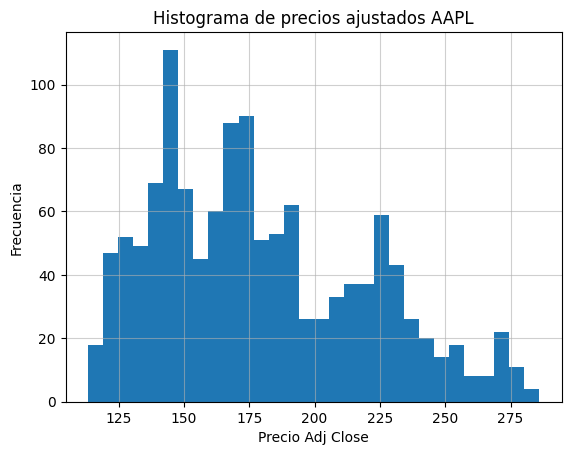

In [ ]:
ticker = "AAPL"
bins = 30
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
s = prices[col].dropna()

plt.figure()
plt.hist(s.values, bins = bins)
plt.title(f"Histograma de precios ajustados {ticker}")
plt.ylabel("Frecuencia")
plt.xlabel("Precio Adj Close")
plt.grid(alpha = 0.6)
plt.show()


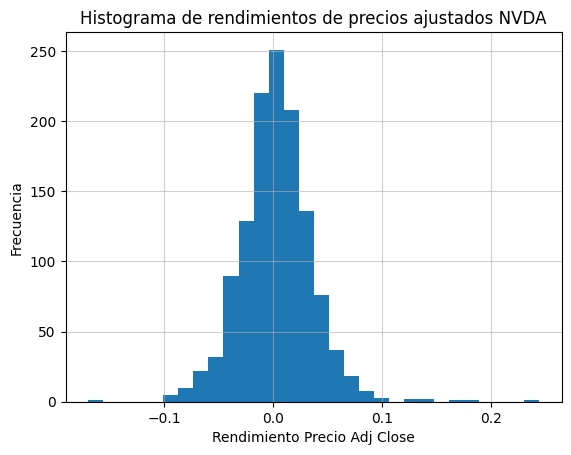

In [ ]:
# hacer histograma de rendimientos
# valor(t)/valr(t-1) - 1

ticker = "NVDA"
bins = 30
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
rend = prices[col].dropna()
rend = rend.pct_change()

plt.figure()
plt.hist(rend.values, bins = bins)
plt.title(f"Histograma de rendimientos de precios ajustados {ticker}")
plt.ylabel("Frecuencia")
plt.xlabel("Rendimiento Precio Adj Close")
plt.grid(alpha = 0.6)
plt.show()

In [ ]:
# rend = prices[col].dropna()
# rendx = rend[1:].values / rend[:-1] - 1
# rendx

In [ ]:
# Histogramas, Heatmap, Boxplot, time series,  time series con área bajo la vcurva, pie chart, barras, scatterplots, bubble plots, grouped stacked bars, waffle charts, violin, Table

### Heatmap

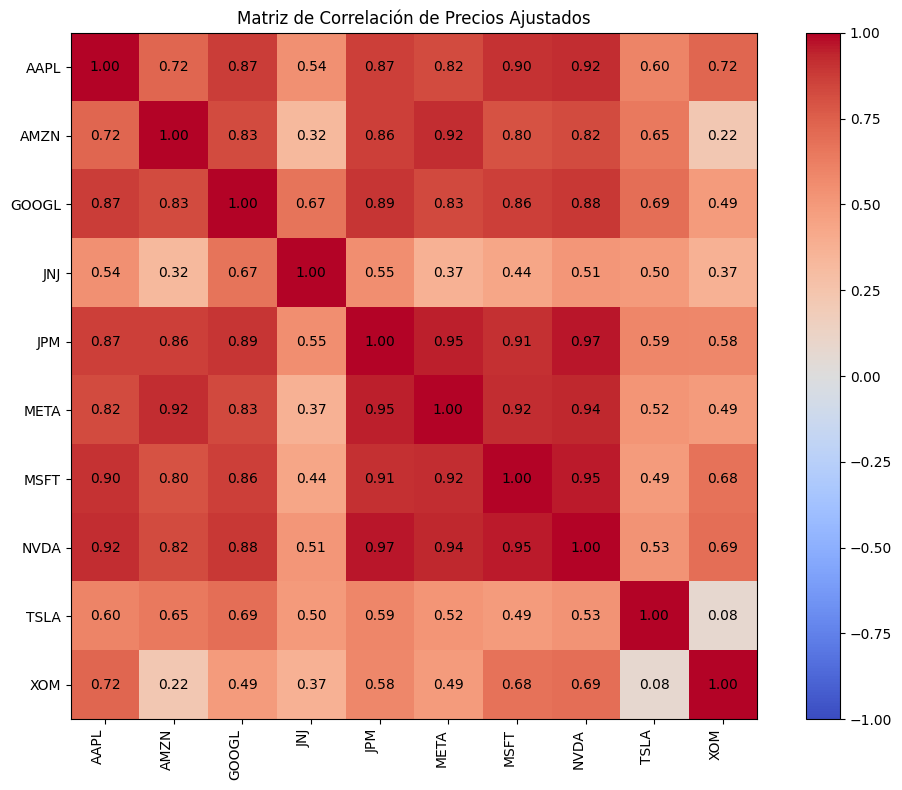

In [31]:
prices_2 = df.copy()
price_cols = [col for col in prices_2.columns if col.startswith("ADJ_CLOSE")]
prices_2 = prices_2[price_cols]

corr = prices_2.corr(method = "pearson")    # Matrix de correlaciones

labels = [c.replace("ADJ_CLOSE_", "") for c in corr.columns]    # Remueve todo menos el ticker
fig, ax = plt.subplots(figsize = (10,8))    # Create a figure containing a single Axes.
im = ax.imshow(corr.values, cmap = "coolwarm", vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "black")

ax.set_title("Matriz de Correlación de Precios Ajustados")
fig.tight_layout()
plt.colorbar(im, ax = ax)
plt.show()

In [ ]:
display(corr)

,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
ADJ_CLOSE_AAPL,1.000000,0.720197,0.872370,0.541149,0.865433,0.821542,0.900263,0.917982,0.596082,0.723974
ADJ_CLOSE_AMZN,0.720197,1.000000,0.826757,0.322267,0.862170,0.918622,0.801995,0.821215,0.647739,0.222131
ADJ_CLOSE_GOOGL,0.872370,0.826757,1.000000,0.671703,0.893941,0.832668,0.861192,0.883093,0.690981,0.488652
ADJ_CLOSE_JNJ,0.541149,0.322267,0.671703,1.000000,0.549742,0.371474,0.435155,0.514480,0.499087,0.367434
ADJ_CLOSE_JPM,0.865433,0.862170,0.893941,0.549742,1.000000,0.951334,0.912539,0.966349,0.588539,0.579129
ADJ_CLOSE_META,0.821542,0.918622,0.832668,0.371474,0.951334,1.000000,0.920448,0.935256,0.518375,0.486916
ADJ_CLOSE_MSFT,0.900263,0.801995,0.861192,0.435155,0.912539,0.920448,1.000000,0.953806,0.489687,0.676819
ADJ_CLOSE_NVDA,0.917982,0.821215,0.883093,0.514480,0.966349,0.935256,0.953806,1.000000,0.527563,0.689505
ADJ_CLOSE_TSLA,0.596082,0.647739,0.690981,0.499087,0.588539,0.518375,0.489687,0.527563,1.000000,0.077925
ADJ_CLOSE_XOM,0.723974,0.222131,0.488652,0.367434,0.579129,0.486916,0.676819,0.689505,0.077925,1.000000


#### Tarea Obtener el heatmap de correlación de rendimientos

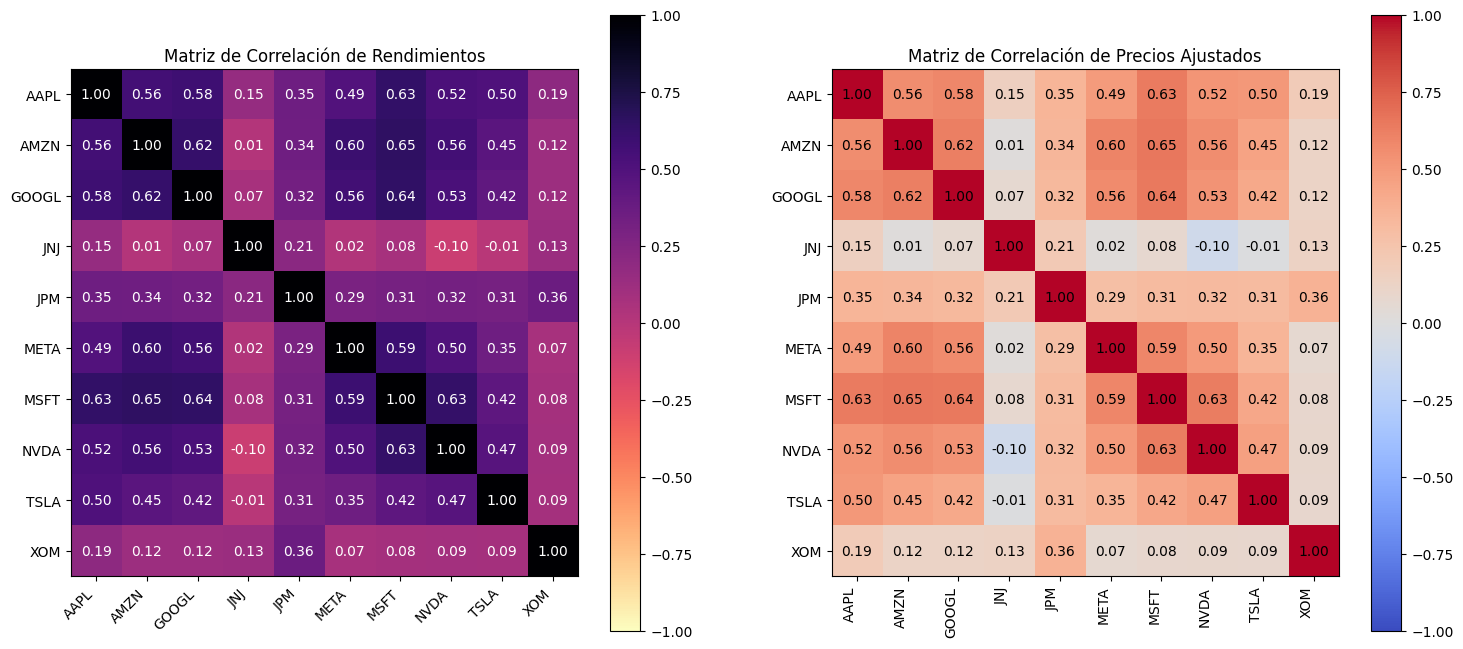

In [32]:
prices_2_v2 = df.copy()
price_cols = [col for col in prices_2.columns if col.startswith("ADJ_CLOSE")]
prices_2_v2 = prices_2_v2[price_cols].dropna()
prices_2_v2 = prices_2_v2.pct_change()

corr = prices_2_v2.corr(method = "pearson")
labels = [c.replace("ADJ_CLOSE_", "") for c in corr.columns]
fig, (ax, ax2) = plt.subplots(1, 2, figsize = (18,8))    # Create a figure containing a single Axes.

im = ax.imshow(corr.values, cmap = "magma_r", vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 45, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "w")

ax.set_title("Matriz de Correlación de Rendimientos")
#fig.tight_layout()
plt.colorbar(im, ax = ax)

im = ax2.imshow(corr.values, cmap = "coolwarm", vmin = -1, vmax = 1)

ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation = 90, ha = "right")
ax2.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax2.text(j, i, f"{corr.values[i,j]:.2f}", ha = "center", va = "center", color = "black")

ax2.set_title("Matriz de Correlación de Precios Ajustados")
#fig.tight_layout()
plt.colorbar(im, ax = ax2)



plt.show()

### Boxplot

C:\Users\hazae\AppData\Local\Temp\ipykernel_23544\3913437965.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(s.values, labels = [ticker], showfliers = True)


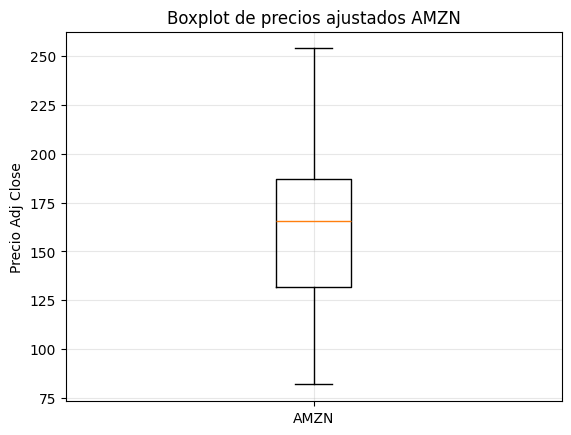

In [ ]:
ticker = "AMZN"
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"
if col not in prices.columns:
    disponibles = ", ".join([c.replace("ADJ_CLOSE_", "") for c in prices.columns if c.startswith("ADJ_CLOSE_")])
    raise ValueError(f"Ticker {ticker} no encontrado. Disponibles: {disponibles}")

s = prices[col].dropna()

plt.figure()
plt.boxplot(s.values, labels = [ticker], showfliers = True)
plt.title(f"Boxplot de precios ajustados {ticker}")
plt.ylabel("Precio Adj Close")
plt.grid(True, alpha = 0.3)
plt.show()

# IQR = Percentil75 - Percentil25
# todo lo que esté por debajo de [Percentil25 - 1.5*IQR] o por encima de [Percentil75 + 1.5*IQR] se considera outlier

# skew
# kurtosis


In [ ]:
# Tarea Obtener boxplot de rendimientos

C:\Users\ossia\AppData\Local\Temp\ipykernel_22816\3880393385.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(s.values, labels = [ticker], showfliers = True)


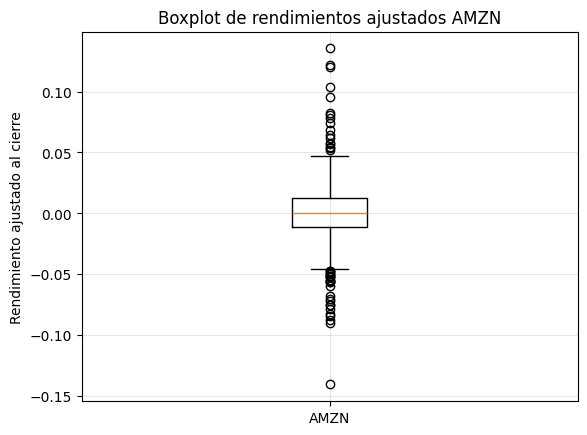

1       0.010004
2      -0.024897
3       0.007577
4       0.006496
5      -0.021519
          ...   
1249    0.016241
1250    0.001034
1251    0.000602
1252   -0.001935
1253    0.001982
Name: ADJ_CLOSE_AMZN, Length: 1253, dtype: float64

In [ ]:
ticker = "AMZN"

col = f"ADJ_CLOSE_{ticker}"
if col not in prices_2_v2.columns:
    disponibles = ", ".join([c.replace("ADJ_CLOSE_", "") for c in prices.columns if c.startswith("ADJ_CLOSE_")])
    raise ValueError(f"Ticker {ticker} no encontrado. Disponibles: {disponibles}")

s = prices_2_v2[col].dropna()

plt.figure()
plt.boxplot(s.values, labels = [ticker], showfliers = True)
plt.title(f"Boxplot de rendimientos ajustados {ticker}")
plt.ylabel("Rendimiento ajustado al cierre")
plt.grid(True, alpha = 0.3)
plt.show()

display(s)

### Serie de Tiempo

C:\Users\ossia\AppData\Local\Temp\ipykernel_18340\3580577236.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y[col] = (s - s.min())/(s.max() - s.min())


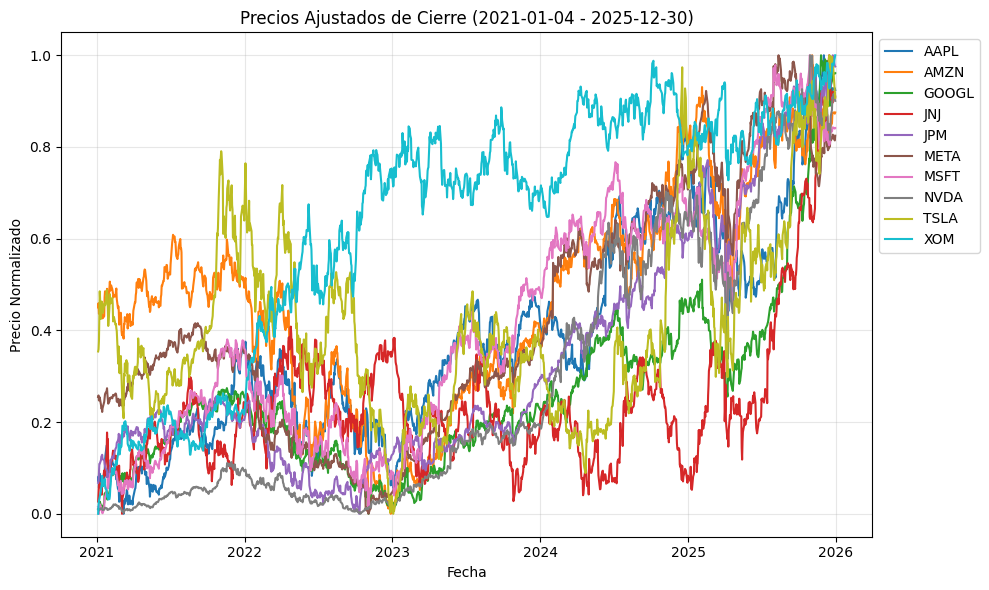

,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
DATE,,,,,,,,,,
2021-01-04,0.072558,0.450177,0.011875,0.026666,0.067612,0.255208,0.015471,0.009518,0.354017,0.000000
2021-01-05,0.081573,0.459435,0.014748,0.046487,0.070178,0.258086,0.016068,0.011001,0.358680,0.018773
2021-01-06,0.056723,0.436166,0.011204,0.062537,0.092436,0.247227,0.000000,0.006977,0.376901,0.029192
2021-01-07,0.081066,0.443071,0.021825,0.068354,0.108734,0.254925,0.017178,0.010692,0.429340,0.032478
2021-01-08,0.087434,0.449036,0.026674,0.064799,0.109300,0.253266,0.020960,0.010350,0.485201,0.037171
...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.919942,0.873040,0.963071,0.895828,0.986182,0.823157,0.839336,0.909004,0.988685,0.981969
2025-12-24,0.928336,0.874434,0.961990,0.920661,1.000000,0.826883,0.842803,0.905940,0.988265,0.979672
2025-12-26,0.925962,0.875247,0.959577,0.918798,0.994626,0.820802,0.841885,0.915745,0.961522,0.978409


In [46]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

display(Y)

In [ ]:
# Tarea: Evolución del valor de lals acciones respecto al año anterior y hace dos años

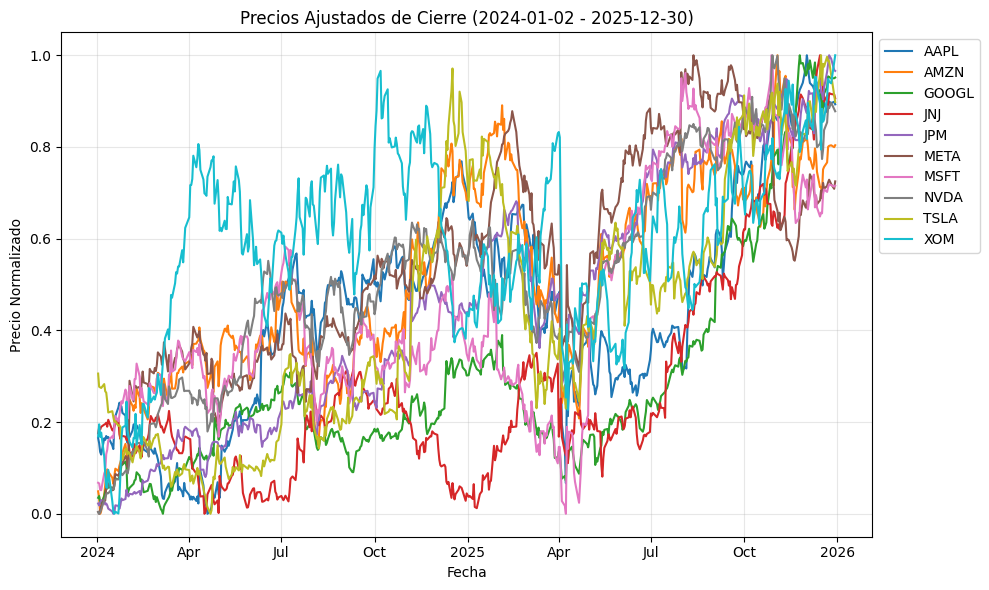

In [ ]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
Y = Y.loc["2024-01-02":"2025-12-30"]    # Solo cambiamos el ano para ajustar la temporalidad


if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

In [ ]:
Y.index

years = re.compile(r"2024|2025")

new_dates = [x for x in Y.index if re.search(years, str(x))]
pd.to_datetime(new_dates, errors="coerce")

DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-16',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[ns]', length=501, freq=None)

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AAPL,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM
753,2024-01-02,183.731323,149.929993,137.037399,149.659760,163.843582,343.593658,364.589478,48.138569,248.419998,...,82488700,47339400,23711200,9622100,9977400,19042200,25258600,411254000,104654200,23483000
754,2024-01-03,182.355621,148.470001,137.781250,150.595306,163.129456,341.787811,364.324005,47.539936,238.449997,...,58414500,49425500,24212100,8232000,9852300,15451100,23083500,320896000,121082600,23490800
755,2024-01-04,180.039658,144.570007,135.271973,150.277222,164.212021,344.417145,361.709076,47.968681,237.929993,...,71983600,56039800,27137700,6766600,11972500,12099900,20901500,306535000,102629300,19395200
756,2024-01-05,179.317139,145.240005,134.617371,150.745026,165.035919,349.209625,361.522247,49.067009,237.490005,...,62379700,45153100,22513900,5602500,10066000,13920700,21004600,415039000,92488900,15827400
757,2024-01-08,183.652145,149.100006,137.701904,151.119232,164.796387,355.867371,368.344788,52.221081,240.449997,...,59144500,46757100,21404000,6569800,11229900,13890200,23134000,642510000,85166600,23370100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100
1252,2025-12-29,273.504089,232.070007,313.339417,206.462418,322.296204,658.126526,485.990753,188.209808,459.640015,...,23715200,19797900,19621800,4348900,8635300,8506500,10893400,120006100,66263000,14782500


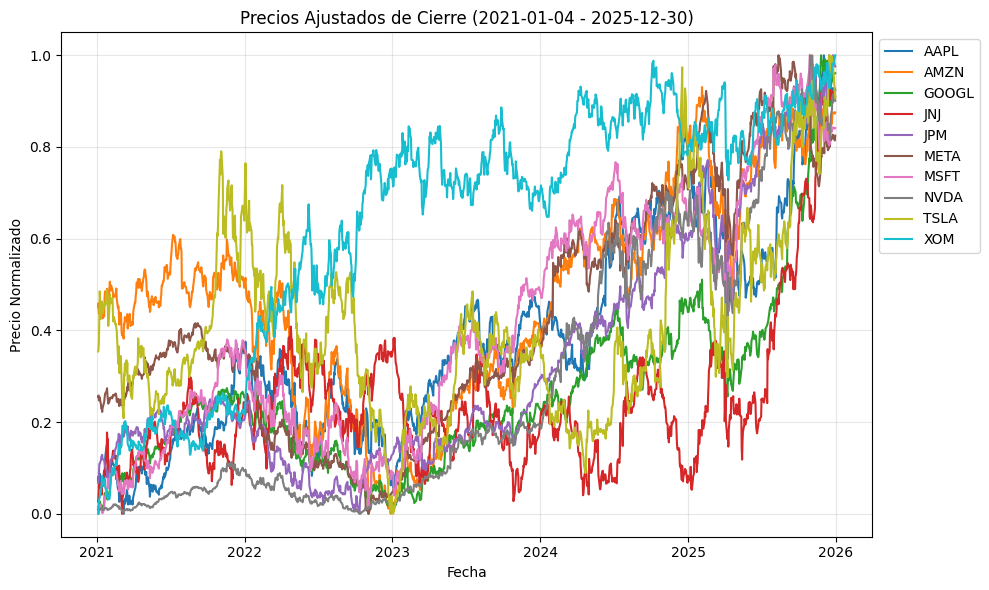

In [ ]:
Y.index

years = re.compile(r"2024|2025")

YY = [x for x in Y.index if re.search(years, str(x))]
YY = pd.to_datetime(YY, errors="coerce")

dfx_v2 = df.copy()
#dfx_v2 = dfx_v2.loc["2024-01-02":"2025-12-30"]
dfx_v2 = dfx_v2.loc[dfx_v2["Date"].isin(YY)]

display(dfx_v2)

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

### Time Series Con Área Bajo la Curva

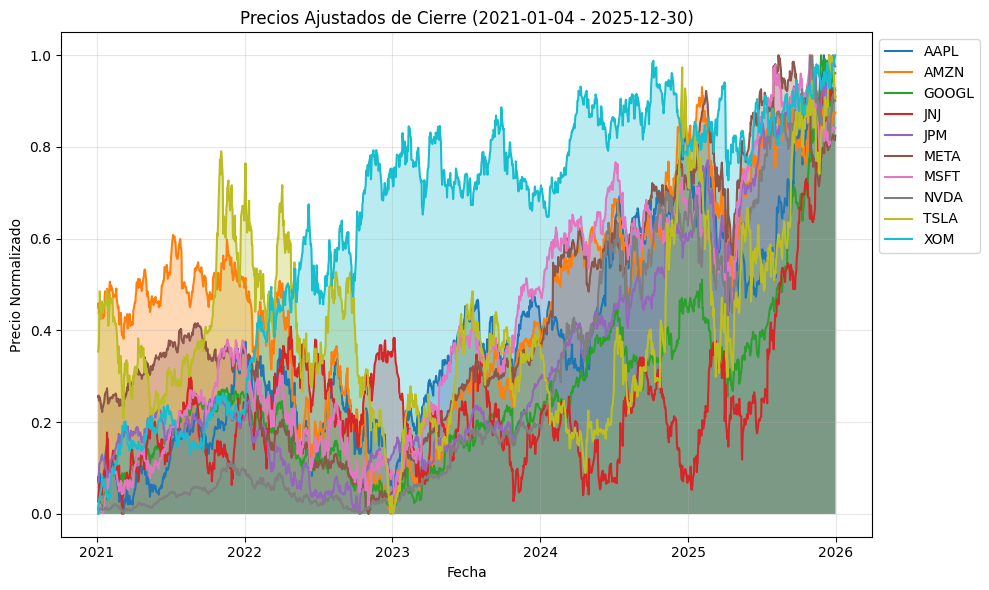

In [ ]:
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.set_index("DATE")

normalize = True

Y = dfx[price_cols]
if normalize:
    for col in price_cols:
        s = Y[col]
        Y[col] = (s - s.min())/(s.max() - s.min())
        # if s.notna().any():
        #     base = s[s.notna()].iloc[0]
        #     Y[col] = (s / base)*100
        # else:
        #     Y[col] = np.nan

fig, ax = plt.subplots(figsize = (10,6))
for col in price_cols:
    series = Y[col]
    if series.notna().any():
        ax.plot(series.index, series.values, label = col.replace("ADJ_CLOSE_", ""))
        ax.fill_between(series.index, series.values, alpha = 0.3)

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

start = Y.index.min()
end = Y.index.max()

ax.set_title(f"Precios Ajustados de Cierre ({start.date()} - {end.date()})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio" + (" Normalizado" if normalize else ""))
ax.grid(True, alpha = 0.3)
ax.legend(loc = "upper left", bbox_to_anchor = (1,1))
fig.tight_layout()
plt.show()

In [ ]:
# Tarea Evolución del valor de lals acciones respecto al año anterior y hace dos años con área bajo la curva

### Pie Chart

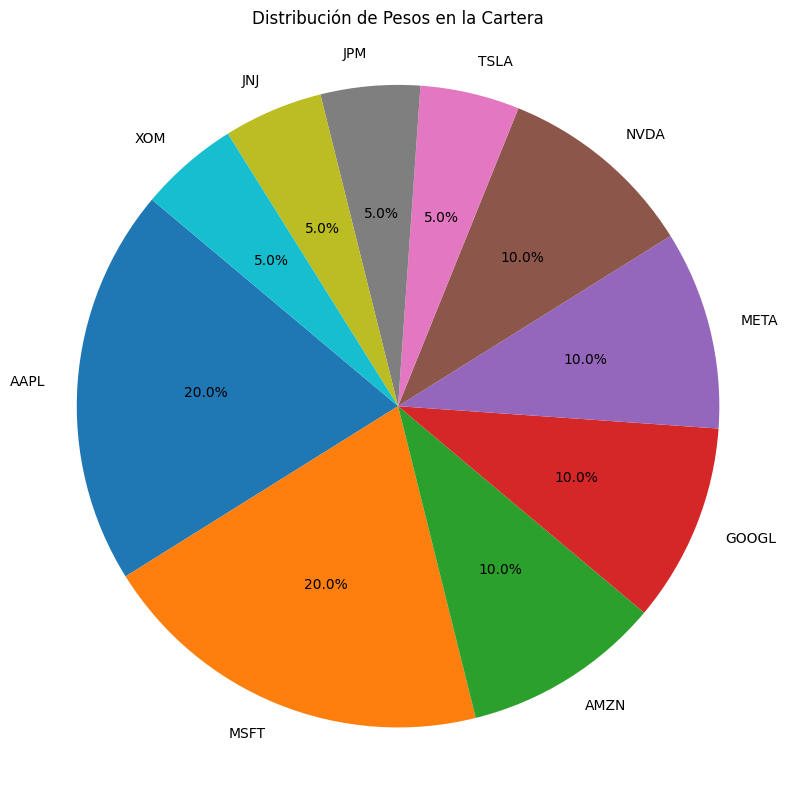

In [ ]:
weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

labels = list(weights.keys())
values = list(weights.values())

plt.figure(figsize = (8,8))
wedges, texts, autotexts = plt.pie(values, labels = labels, autopct = "%1.1f%%", startangle = 140)
plt.title("Distribución de Pesos en la Cartera")
plt.axis("equal")
plt.tight_layout()
plt.show()


In [ ]:
# Tarea: piechart con la proporción del rendimiento total aportada por acción

## Grafico de barras

In [ ]:
# Grafico de barras con el rendimiento acumulado del portafolio para el ultimo ano, acumulado por mes - para todo el portagolio





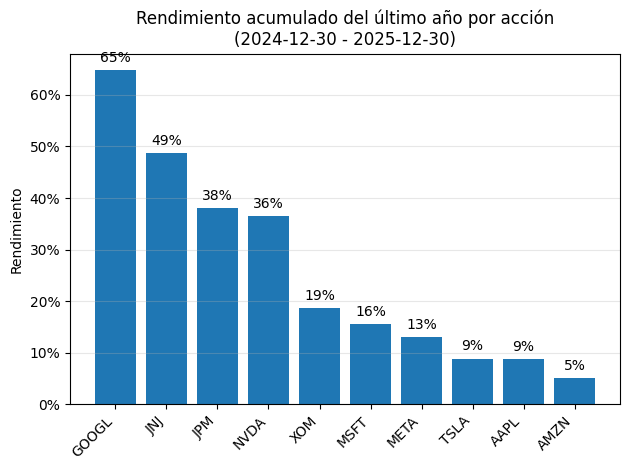

In [37]:
# rend acumulado del último año para cada acción
 
price_cols = [col for col in df.columns if col.startswith("ADJ_CLOSE")]
 
dfx = df.copy()
dfx["DATE"] = pd.to_datetime(dfx["Date"], errors = "coerce")
dfx = dfx.sort_values("DATE")
 
end = dfx["DATE"].max()
start = end - pd.DateOffset(years=1)
 
sub = dfx.loc[(dfx["DATE"] >= start) & (dfx["DATE"] <= end)]
 
rets = {}
for col in price_cols:
    s = sub[col].dropna()
    ticker = col.replace("ADJ_CLOSE_","")
    rets[ticker] = s.iloc[-1]/s.iloc[0] - 1
 
res = pd.Series(rets).sort_values(ascending = False)
tickers = res.index.to_list()
values = res.values
 
fig, ax = plt.subplots()
x = np.arange(len(tickers))
bars = ax.bar(x, values)
 
ax.set_xticks(x)
ax.set_xticklabels(tickers, rotation = 45, ha = "right")
ax.set_title(f"Rendimiento acumulado del último año por acción\n({start.date()} - {end.date()})")
ax.set_ylabel("Rendimiento")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(True, axis = "y", alpha = 0.3)
 
for xi, v in zip(x, values):
    ax.text(xi, v + (0.01 if v >= 0 else -0.01), f"{v:.0%}",
            ha = "center", va = "bottom" if v >= 0 else "top")
 
fig.tight_layout()
plt.show()

weights = {"AAPL": 0.2, "MSFT": 0.2, "AMZN": 0.1, "GOOGL": 0.1, "META": 0.1, "NVDA": 0.1, "TSLA": 0.05, "JPM": 0.05, "JNJ": 0.05, "XOM": 0.05}

In [ ]:



dfx

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,DATE
0,2021-01-04,125.856705,159.331497,85.599030,135.059677,110.051888,266.845917,208.406494,13.076019,243.256668,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,2021-01-04
1,2021-01-05,127.412727,160.925507,86.289314,136.647568,110.650734,268.860138,208.607574,13.366435,245.036667,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,2021-01-05
2,2021-01-06,123.123848,156.919006,85.437851,137.933472,115.846428,261.259827,203.198517,12.578445,251.993332,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,2021-01-06
3,2021-01-07,127.325241,158.108002,87.989761,138.399490,119.650742,266.647461,208.980942,13.305861,272.013336,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,2021-01-07
4,2021-01-08,128.424210,159.134995,89.154633,138.114685,119.782852,265.486664,210.254227,13.238802,293.339996,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,2021-01-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600,2025-12-23
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400,2025-12-24
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100,2025-12-26
1252,2025-12-29,273.504089,232.070007,313.339417,206.462418,322.296204,658.126526,485.990753,188.209808,459.640015,...,19797900,19621800,4348900,8635300,8506500,10893400,120006100,66263000,14782500,2025-12-29


In [45]:
## Tarea: Grafico de barras con el rendimiento acumulado del portafolio para el ultimo ano, acumulado por mes - para todo el portagolio

df_grafico_barras = dfx.copy()

price_cols = [col for col in df_grafico_barras.columns if col.startswith("ADJ_CLOSE")]
df_grafico_barras["DATE"] = pd.to_datetime(df_grafico_barras["Date"], errors = "coerce")
df_grafico_barras = df_grafico_barras.sort_values("DATE")

#df_grafico_barras = df_grafico_barras.dropna()
#df_grafico_barras = df_grafico_barras.pct_change()

df_grafico_barras

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUME_AMZN,VOLUME_GOOGL,VOLUME_JNJ,VOLUME_JPM,VOLUME_META,VOLUME_MSFT,VOLUME_NVDA,VOLUME_TSLA,VOLUME_XOM,DATE
0,2021-01-04,125.856705,159.331497,85.599030,135.059677,110.051888,266.845917,208.406494,13.076019,243.256668,...,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700,2021-01-04
1,2021-01-05,127.412727,160.925507,86.289314,136.647568,110.650734,268.860138,208.607574,13.366435,245.036667,...,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100,2021-01-05
2,2021-01-06,123.123848,156.919006,85.437851,137.933472,115.846428,261.259827,203.198517,12.578445,251.993332,...,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800,2021-01-06
3,2021-01-07,127.325241,158.108002,87.989761,138.399490,119.650742,266.647461,208.980942,13.305861,272.013336,...,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100,2021-01-07
4,2021-01-08,128.424210,159.134995,89.154633,138.114685,119.782852,265.486664,210.254227,13.238802,293.339996,...,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200,2021-01-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600,2025-12-23
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400,2025-12-24
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100,2025-12-26
1252,2025-12-29,273.504089,232.070007,313.339417,206.462418,322.296204,658.126526,485.990753,188.209808,459.640015,...,19797900,19621800,4348900,8635300,8506500,10893400,120006100,66263000,14782500,2025-12-29


In [ ]:
el cuadrado de mis elementos